# Churn Modeling

Build a machine learning classification model using XGBoost to predict whether a bank customer is likely to leave the bank. 
    
The target variable for this project is ```Exited```.
    
**Project Tasks**
1. Perform Exploratory Data Analysis (EDA) to understand the dataset and identify patterns.
3. Clean the dataset by removing unnecessary variables and handling any inconsistencies.
    * Encode categorical variables appropriately.
3. Train an XGBoost classification model.
4. Evaluate the model’s performance using appropriate metrics.
5. Analyze and interpret feature importance.
6. Improve the model through hyperparameter tuning.

**Questions to Address**
* Which features influence customer churn the most?
* Do older customers tend to churn more frequently?
* Does account balance have an impact on churn?
* Does being an active member reduce the likelihood of churn?

In [1]:
try:
    import xgboost
except ImportError:
    !pip install xgboost
    import xgboost

In [2]:
import csv
import xgboost as xgb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import FunctionTransformer

In [3]:
# Read the data
churn_data = pd.read_csv("Churn_Modeling.csv")

## Exploratory Data Analysis

In [4]:
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# Drop columns that are unecessary for analysis
churn_data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [6]:
# Convert column names to snake_case to to simplify the workflow
churn_data = churn_data.rename(columns={
    'CreditScore': 'credit_score',
    'Geography': 'geography',
    'Gender': 'gender',
    'Age': 'age',
    'Tenure': 'tenure',
    'Balance': 'balance',
    'NumOfProducts': 'num_of_products',
    'HasCrCard': 'has_credit_card',
    'IsActiveMember': 'is_active_member',
    'EstimatedSalary': 'estimated_salary',
    'Exited': 'exited'
})

In [7]:
churn_data.head()

,credit_score,geography,gender,age,tenure,balance,num_of_products,has_credit_card,is_active_member,estimated_salary,exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      10000 non-null  int64  
 1   geography         10000 non-null  object 
 2   gender            10000 non-null  object 
 3   age               10000 non-null  int64  
 4   tenure            10000 non-null  int64  
 5   balance           10000 non-null  float64
 6   num_of_products   10000 non-null  int64  
 7   has_credit_card   10000 non-null  int64  
 8   is_active_member  10000 non-null  int64  
 9   estimated_salary  10000 non-null  float64
 10  exited            10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


> The churn_data dataset does not have missing values.

In [9]:
print(f"Total number of duplicate rows: {churn_data.duplicated().sum()}")

Total number of duplicate rows: 0


> The churn_data dataset does not have duplicate rows.

In [10]:
churn_data[['credit_score', 'age', 'tenure', 'balance', 'num_of_products', 'estimated_salary']].describe()

,credit_score,age,tenure,balance,num_of_products,estimated_salary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


### Data Anomalies

The min salary 11.58 looks very suspicious.

In [11]:
# The lowest salaries
churn_data[churn_data['estimated_salary'] < 500].sort_values('estimated_salary')[
    ['estimated_salary', 'balance', 'geography', 'age', 'num_of_products']
].head(10)

,estimated_salary,balance,geography,age,num_of_products
2362,11.58,122917.71,Germany,45,1
9647,90.07,0.00,France,31,2
9010,91.75,121669.93,Germany,59,2
5548,96.27,0.00,France,38,2
4989,106.67,0.00,France,40,1
7565,123.07,105355.81,France,52,1
2498,142.81,0.00,France,37,2
8722,143.34,87619.29,France,35,1
4774,178.19,0.00,France,35,1
1451,216.27,0.00,France,38,2


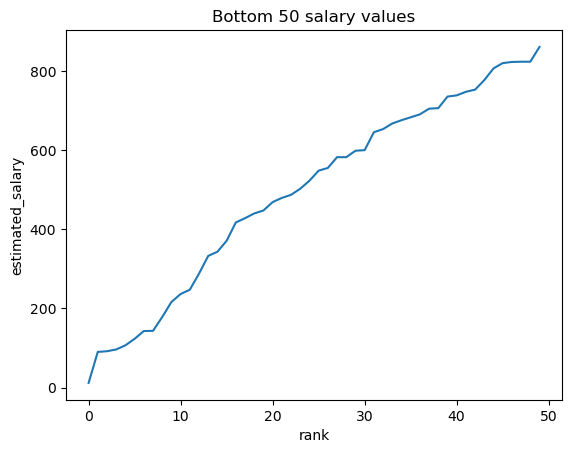

In [12]:
churn_data["estimated_salary"].sort_values().reset_index(drop=True).head(50).plot()
plt.ylabel("estimated_salary")
plt.xlabel('rank')
plt.title('Bottom 50 salary values')
plt.show()

> The `estimated_salary` column contains suspicious values: some customers have very low salaries (less than 500) combined with high account balances (more than 100,000).
>
> As for now, there is no way of finding a threshold between possible errors and really low salaries (some accounts of low-income clients are zero-balanced), so I will decide how to deal with the `estimated_salary` feature later after I analyze its importance.

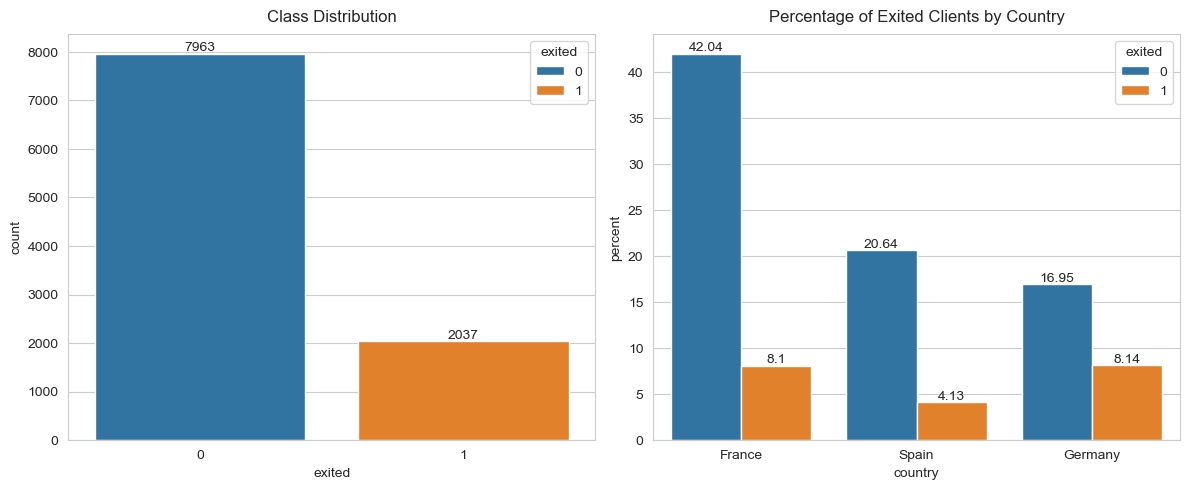

In [13]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Class distribution
ax1 = sns.countplot(churn_data, x="exited", hue="exited", ax=axes[0])
ax1.bar_label(ax1.containers[0]) 
ax1.bar_label(ax1.containers[1]) 
ax1.set_title("Class Distribution", y=1.01)

# Percentage of exited clients
ax2 = sns.countplot(churn_data, x="geography", hue="exited", stat="percent", ax=axes[1])
ax2.bar_label(ax2.containers[0]) 
ax2.bar_label(ax2.containers[1]) 
ax2.set_title("Percentage of Exited Clients by Country", y=1.01)
ax2.set_xlabel("country")

plt.tight_layout()
plt.show()

> The number of stayed clients is 4 times as large as the number of churned clients, so the classes are slightly imbalanced.

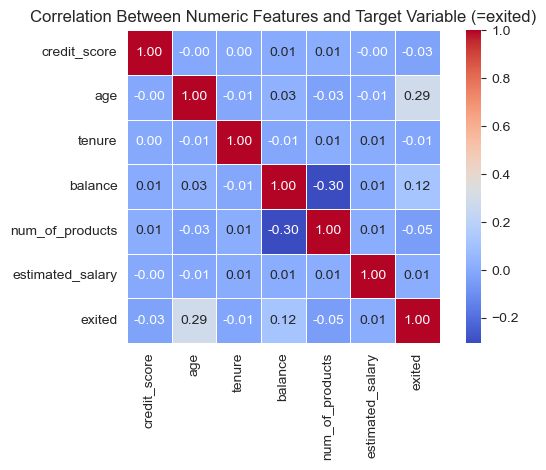

In [14]:
# Check linear correlations between numeric features and target variable
corr_matrix = churn_data[['credit_score', 'age', 'tenure', 'balance', 'num_of_products', 'estimated_salary', 'exited']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Between Numeric Features and Target Variable (=exited)')
plt.tight_layout()
plt.show()

#### Correlation Matrix Interpretation
Top-3 features with linear correlation with the target variable:
* age (0.29)
* balance (0.12)
* number of products (-0.05)

Actually, all correlations with target variable are very weak, except for `age`.

The `estimated_salary` has almost no linear correlation with any of the features, nor with the target variable (0.01).

There is a strong correlation between `num_of_products` and `balance`.

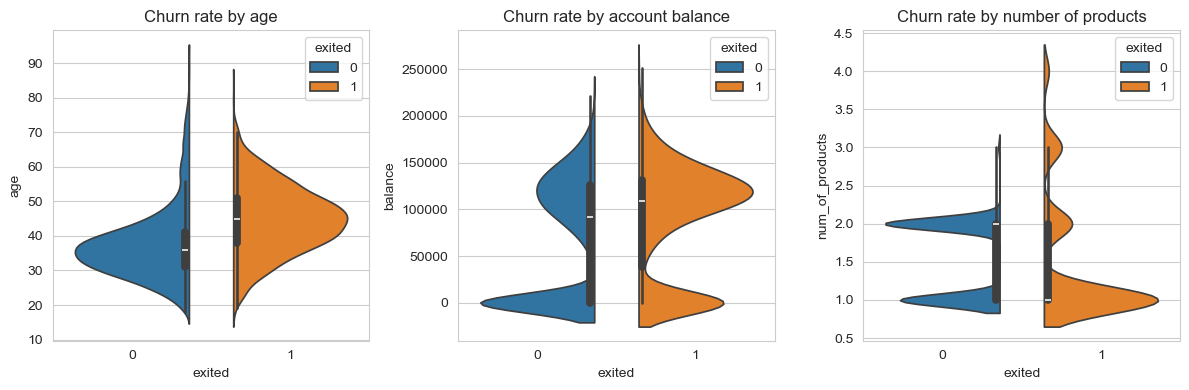

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.violinplot(churn_data, x="exited", y="age", hue="exited", split=True, gap=.1, ax=axes[0])
axes[0].set_title("Churn rate by age")

sns.violinplot(churn_data, x="exited", y="balance", hue="exited", split=True, gap=.1, ax=axes[1])
axes[1].set_title("Churn rate by account balance")

sns.violinplot(churn_data, x="exited", y="num_of_products", hue="exited", split=True, gap=.1, ax=axes[2])
axes[2].set_title("Churn rate by number of products")

plt.tight_layout()
plt.show()

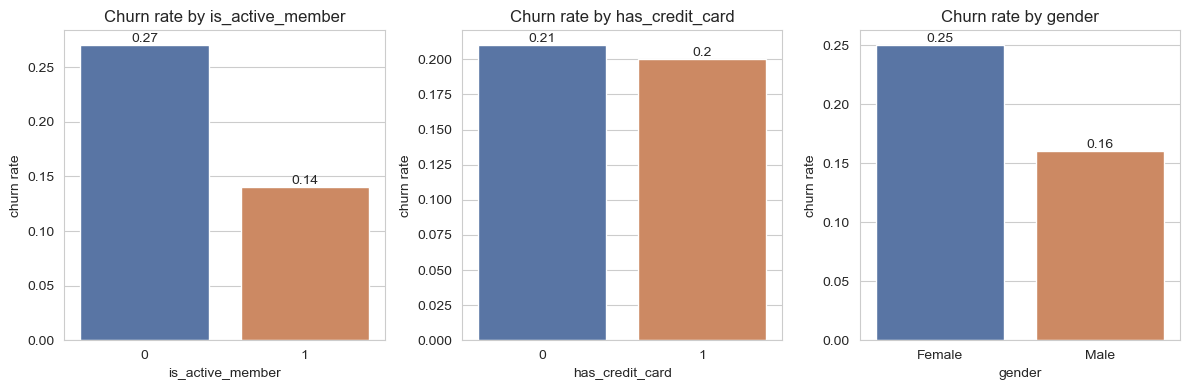

In [16]:
# Influence of binary features
binary_features = ['is_active_member', 'has_credit_card', 'gender']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, feature in zip(axes, binary_features):
    churn_rate = churn_data.groupby(feature)['exited'].mean().round(2).reset_index()
    churn_rate.columns = [feature, 'churn_rate']

    sns.barplot(churn_rate, x=feature, y='churn_rate', hue=feature, palette='deep', ax=ax, legend=False)
    ax.set_title(f'Churn rate by {feature}')
    ax.bar_label(ax.containers[0]) 
    ax.bar_label(ax.containers[1])
    ax.set_ylabel('churn rate')
plt.tight_layout()

## Data Insights Drawn from EDA
* **Georgraphy**
    * Clients from Spain exhibit the lowest risk of churn.
    * Customers from France are the most loyal ones.
* **Age**
    * Older clients tend to churn more often than the younger ones (45 years median age vs 35 years median age).
* **Account balance**
    * There are a lot of clients with 0 balance.
    * Clients with 0 balance are more often current customers.
    * Clients with 75-150k are more likely to churn.
* **Number of products**
    * 1 product: high churn risk, this is the largest group among customers who left.
    * 2 products: the most loyal customers.
    * 3-4 products: almost all of these clients churn, but this group is overall very small.
* **Being an active member**
    * Being an active member significantly reduces the churn likelihood.
* **Having a credit card**
    * Having a credit card is almost irrelevant for predicting churn.
* **Gender**
    * Women churn more often than men.

## XGBoost Classification Model

In [17]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

In [18]:
X = churn_data.drop('exited', axis=1)
y = churn_data['exited']

In [19]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=123)

In [20]:
preprocessor = ColumnTransformer([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False), ['geography', 'gender']),
    ('binary', 'passthrough', ['has_credit_card', 'is_active_member']),
    ('numeric', 'passthrough', ['credit_score', 'age', 'tenure', 'balance', 'num_of_products', 'estimated_salary'])
])

In [21]:
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier())
])

In [22]:
xgb_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoder', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [23]:
y_pred = xgb_pipe.predict(X_test)
y_pred_proba = xgb_pipe.predict_proba(X_test)[:, 1]

In [24]:
baseline_roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Baseline ROC-AUC: {baseline_roc_auc:.4f}")
print("\nClassification report for baseline XGBoost model\n")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Exited']))

baseline_report_dict = classification_report(y_test, y_pred, target_names=['Stayed', 'Exited'], output_dict=True)

Baseline ROC-AUC: 0.8549

Classification report for baseline XGBoost model

              precision    recall  f1-score   support

      Stayed       0.88      0.94      0.91      1586
      Exited       0.70      0.51      0.59       414

    accuracy                           0.85      2000
   macro avg       0.79      0.72      0.75      2000
weighted avg       0.84      0.85      0.84      2000



In [25]:
print("\nConfusion matrix for baseline XGBoost model\n")
print(confusion_matrix(y_test, y_pred))


Confusion matrix for baseline XGBoost model

[[1495   91]
 [ 204  210]]


### Model Performance

The model shows strong performance in identifying clients with low risk of churn (`94%` recall), but misses every other customer who is about to leave (`51%` recall).

Even though the accuracy of the model is high (`85%`), the recall of `51%` is a major concern.

In [26]:
feature_names = xgb_pipe.named_steps['preprocessor'].get_feature_names_out()
print("Feature names")
print(feature_names)

Feature names
['encoder__geography_Germany' 'encoder__geography_Spain'
 'encoder__gender_Male' 'binary__has_credit_card'
 'binary__is_active_member' 'numeric__credit_score' 'numeric__age'
 'numeric__tenure' 'numeric__balance' 'numeric__num_of_products'
 'numeric__estimated_salary']


In [27]:
importance_baseline = xgb_pipe.named_steps['classifier'].feature_importances_

feat_imp_baseline = pd.DataFrame({
    'feature': feature_names,
    'importance': importance_baseline
}).sort_values('importance', ascending=False
)

feat_imp_baseline['feature'] = feat_imp_baseline['feature'].apply(lambda x: x.split('__')[-1])

print(feat_imp_baseline.to_string(index=False))

          feature  importance
  num_of_products    0.285622
 is_active_member    0.191541
              age    0.127304
geography_Germany    0.098967
          balance    0.056256
  geography_Spain    0.048956
      gender_Male    0.047942
 estimated_salary    0.038834
     credit_score    0.037942
  has_credit_card    0.033565
           tenure    0.033069


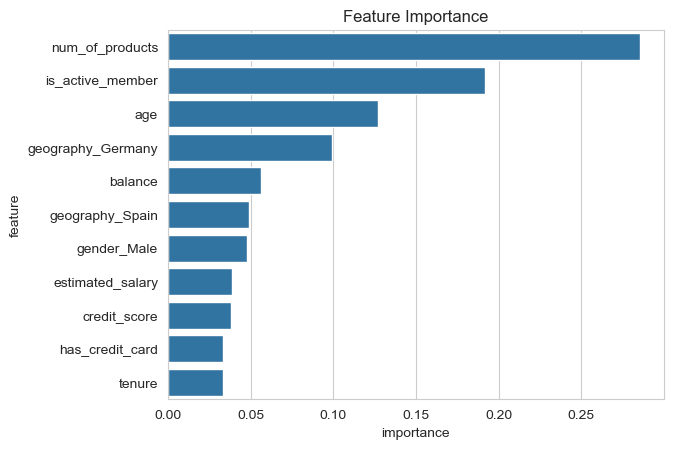

In [28]:
sns.barplot(feat_imp_baseline, x='importance', y='feature')
plt.title('Feature Importance')
plt.show()

### Feature Importance

The Top-3 features that influence customer's intention to churn:
* `num_of_products`
* `is_active_member`
* `age`

> Given the low `estimated_salary` importance and its almost zero linear correlation with both target variable and other features, the suspiciously low salary values are unlikely to significantly impact model performance, so they are left as they are.

## Hyperparameter Optimization

Hyperparameter tuning is aimed to improve the low recall for churned clients (51%) .It is performed in two steps. 
    
First, tree parameters (`max_depth`, `n_estimators`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`) are optimized using `ROC-AUC` scoring to find the best structure.
    
Step 2 fixes the structure from Step 1 and optimizes class imbalance parameters `scale_pos_weight` and `gamma` using `ROC-AUC` as recommended by [XGBoost documentation](https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html). 

### Step 1: Tree Structure Optimization

In [29]:
params_structure = {
    'classifier__max_depth': np.arange(3, 8, 1),
    'classifier__min_child_weight': np.arange(1, 8, 1),
    'classifier__n_estimators': np.arange(25, 301, 25),
    'classifier__learning_rate': np.linspace(0.01, 1.0, 20), # range: [0,1], default=0.5
    'classifier__colsample_bytree': np.arange(0.1, 1, 0.1), # range: (0,1], default=1
    'classifier__subsample': np.arange(0.5, 1, 0.1), # range: (0,1], default=1,
}

search_structure = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=params_structure,
    n_iter=50,
    cv=5, 
    scoring='roc_auc',
    random_state=42, 
    n_jobs=-1
)

search_structure.fit(X_train, y_train)

best_params_structure = search_structure.best_params_
print(f"ROC-AUC: {search_structure.best_score_:.4f}")
for param_name, param_value in search_structure.best_params_.items():
    print(f"{param_name}: {param_value}")


ROC-AUC: 0.8624
classifier__subsample: 0.7999999999999999
classifier__n_estimators: 25
classifier__min_child_weight: 2
classifier__max_depth: 5
classifier__learning_rate: 0.16631578947368422
classifier__colsample_bytree: 0.5


In [30]:
xgb_pipe.set_params(**search_structure.best_params_)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoder', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

### Step 2: Class Balancing

In [31]:
# A value to consider when balancing positive and negative weights: sum(negative instances) / sum(positive instances)
spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"spw value to consider: {spw:.2f}")

spw value to consider: 3.93


In [32]:
params_balanced_roc = {
    'classifier__scale_pos_weight': np.arange(3, 8, 1), # default=1
    'classifier__gamma': [0, 0.05, 0.1, 0.2]
}

search_balance_roc = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=params_balanced_roc,
    n_iter=20,
    cv=5, 
    scoring='roc_auc',
    random_state=42, 
    n_jobs=-1
)

search_balance_roc.fit(X_train, y_train)

best_params_roc = search_balance_roc.best_params_
print(f"ROC-AUC: {search_balance_roc.best_score_:.4f}")
for param_name, param_value in search_balance_roc.best_params_.items():
    print(f"{param_name}: {param_value}")


ROC-AUC: 0.8619
classifier__scale_pos_weight: 3
classifier__gamma: 0.2


In [33]:
xgb_pipe.set_params(**search_balance_roc.best_params_)
xgb_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoder', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [34]:
y_pred = xgb_pipe.predict(X_test)
y_pred_proba = xgb_pipe.predict_proba(X_test)[:, 1]

In [35]:
tuned_roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC for tuned model: {tuned_roc_auc:.4f}")
print("\nClassification Report for Tuned Model:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Exited']))
tuned_report_dict = classification_report(y_test, y_pred, target_names=['Stayed', 'Exited'], output_dict=True)

print("Confusion Matrix for tuned model:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC for tuned model: 0.8779

Classification Report for Tuned Model:
              precision    recall  f1-score   support

      Stayed       0.92      0.87      0.90      1586
      Exited       0.59      0.71      0.64       414

    accuracy                           0.84      2000
   macro avg       0.76      0.79      0.77      2000
weighted avg       0.85      0.84      0.84      2000

Confusion Matrix for tuned model:
[[1384  202]
 [ 121  293]]


## Hyperparameter Tuning: Model Comparison

In [36]:
def extract_metrics(model, report_dict, roc_auc):
    return {
        'Model': model,
        'ROC-AUC': round(roc_auc, 2),
        'Precision (Exited)': round(report_dict['Exited']['precision'], 2),
        'Recall (Exited)': round(report_dict['Exited']['recall'], 2),
        'F1 (Exited)': round(report_dict['Exited']['f1-score'], 2),
        'Recall (Stayed)': round(report_dict['Stayed']['recall'], 2),
        'Accuracy': round(report_dict['accuracy'], 2),
    }

model_comparison = pd.DataFrame([
    extract_metrics('Baseline', baseline_report_dict, baseline_roc_auc),
    extract_metrics('Tuned', tuned_report_dict, tuned_roc_auc),
]).set_index('Model')

print(model_comparison.T)

Model               Baseline  Tuned
ROC-AUC                 0.85   0.88
Precision (Exited)      0.70   0.59
Recall (Exited)         0.51   0.71
F1 (Exited)             0.59   0.64
Recall (Stayed)         0.94   0.87
Accuracy                0.85   0.84


Hyperparameter tuning improved the XGBoost model across key metrics. 
    
* **ROC-AUC** increased from 85% to 88%, indicating better overall discrimination between classes.
* **Recall** for churned customers improved from 51% to 71%: the model now correctly identifies 71% of customers at risk of leaving, compared to 51% in the baseline.
* There is a slight decrease in **Precision** (from 70% to 59%), but this trade-off is acceptable as missing churned clients was the biggest point of concern.

## Feature Engineering Experiment

In [37]:
from sklearn.preprocessing import FunctionTransformer

Tree-based models often benefit from engineered ratios, so I will try to improve the model performance by considering `balance_to_salary` and `tenure_to_age` features.

While using the raw features, I decided to ignore extremely low salaries because the `estimated_salary` feature was of low importance. However, having such low values in the denominator of the `balance_to_salary` feature would distort the ratio by producing extremely large values. To address the problem, salary values below the 1st percentile (~1,843) were capped at the threshold value. This approach affects only 100 records (1% of the dataset) rather than legitimate low-income customers.

In [38]:
# Count the salary percentiles and affected rows
for p in [0.01, 0.02, 0.05]:
    threshold = churn_data['estimated_salary'].quantile(p)
    count = (churn_data['estimated_salary'] < threshold).sum()
    print(f"Percentile {p*100:.0f}%: salary threshold={threshold:.0f}, affected rows={count}")

Percentile 1%: salary threshold=1843, affected rows=100
Percentile 2%: salary threshold=3769, affected rows=200
Percentile 5%: salary threshold=9852, affected rows=500


In [39]:
churn_data_eng = churn_data.copy()

# Cap values below the salary threshold
salary_threshold = churn_data_eng['estimated_salary'].quantile(0.01)
churn_data_eng['estimated_salary'] = churn_data_eng['estimated_salary'].clip(lower=salary_threshold)

In [40]:
X_eng = churn_data_eng.drop('exited', axis=1)
y_eng = churn_data_eng['exited']

# Split the data using the same seed
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=123)

### Feature Selection

In [41]:
def add_balance_to_salary(X):
    X = X.copy()
    X['balance_to_salary'] = X['balance'] / X['estimated_salary']
    return X

def add_tenure_to_age(X):
    X = X.copy()
    X['tenure_to_age'] = X['tenure'] / X['age']
    return X

In [42]:
# Preprocessor for both balance_to_salary and tenure_to_age engineered features
preprocessor_eng = ColumnTransformer([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False), ['geography', 'gender']),
    ('binary', 'passthrough', ['has_credit_card', 'is_active_member']),
    ('numeric', 'passthrough', ['credit_score', 'age', 'tenure', 'balance', 'num_of_products', 'estimated_salary', 'balance_to_salary', 'tenure_to_age'])
])

In [43]:
# Pipeline for a model with both balance_to_salary and tenure_to_age engineered features
xgb_pipe_eng = Pipeline([
    ('add_balance_to_salary', FunctionTransformer(add_balance_to_salary)),
    ('add_tenure_to_age', FunctionTransformer(add_tenure_to_age)),
    ('preprocessor', preprocessor_eng),
    ('classifier', xgb.XGBClassifier())
])

xgb_pipe_eng.fit(X_train_eng, y_train_eng)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('add_balance_to_salary', ...), ('add_tenure_to_age', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001DC0D156520>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional 

In [44]:
feature_names_eng = xgb_pipe_eng.named_steps['preprocessor'].get_feature_names_out()
importance_eng = xgb_pipe_eng.named_steps['classifier'].feature_importances_

feat_imp_eng = pd.DataFrame({
    'feature': feature_names_eng,
    'importance': importance_eng
}).sort_values('importance', ascending=False)

feat_imp_eng['feature'] = feat_imp_eng['feature'].apply(lambda x: x.split('__')[-1])

print(f"Baseline Model:\n {feat_imp_baseline.to_string(index=False)}")
print(f"\nFeature-Engineered Model:\n {feat_imp_eng.to_string(index=False)}")

Baseline Model:
           feature  importance
  num_of_products    0.285622
 is_active_member    0.191541
              age    0.127304
geography_Germany    0.098967
          balance    0.056256
  geography_Spain    0.048956
      gender_Male    0.047942
 estimated_salary    0.038834
     credit_score    0.037942
  has_credit_card    0.033565
           tenure    0.033069

Feature-Engineered Model:
           feature  importance
  num_of_products    0.272074
 is_active_member    0.181143
              age    0.120800
geography_Germany    0.080563
          balance    0.047463
      gender_Male    0.047022
balance_to_salary    0.045313
  geography_Spain    0.041853
  has_credit_card    0.035183
    tenure_to_age    0.034424
     credit_score    0.032063
 estimated_salary    0.031582
           tenure    0.030516


Both engineered features were evaluated by comparing their importance scores to the baseline model. 
    
* `balance_to_salary` had an importance of 0.045, comparable to balance (0.047), suggesting that the ratio captures additional information not fully represented by raw values.
* `tenure_to_age` showed minimal improvement over tenure alone (0.034 vs 0.033), indicating that the ratio does not add meaningful predictive value.
    
Therefore, only `balance_to_salary` was retained for further tuning.

### Feature-Engineered Model Building

In [45]:
preprocessor_eng = ColumnTransformer([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False), ['geography', 'gender']),
    ('binary', 'passthrough', ['has_credit_card', 'is_active_member']),
    ('numeric', 'passthrough', ['credit_score', 'age', 'tenure', 'balance', 'num_of_products', 'estimated_salary', 'balance_to_salary'])
])

# Pipeline for a model the balance_to_salary engineered feature
xgb_pipe_eng = Pipeline([
    ('add_balance_to_salary', FunctionTransformer(add_balance_to_salary)),
    ('preprocessor', preprocessor_eng),
    ('classifier', xgb.XGBClassifier())
])

xgb_pipe_eng.fit(X_train_eng, y_train_eng)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('add_balance_to_salary', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001DC0D156520>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keywo

In [46]:
y_pred_eng = xgb_pipe_eng.predict(X_test_eng)
y_pred_proba = xgb_pipe_eng.predict_proba(X_test_eng)[:, 1]

In [47]:
eng_roc_auc = roc_auc_score(y_test_eng, y_pred_proba)
print(f"ROC-AUC for Engineered Model: {eng_roc_auc:.4f}")
print("\nClassification Report for Feature-Engineered Model:")
print(classification_report(y_test_eng, y_pred_eng, target_names=['Stayed', 'Exited']))
eng_report_dict = classification_report(y_test_eng, y_pred_eng, target_names=['Stayed', 'Exited'], output_dict=True)

ROC-AUC for Engineered Model: 0.8572

Classification Report for Feature-Engineered Model:
              precision    recall  f1-score   support

      Stayed       0.88      0.94      0.91      1586
      Exited       0.70      0.50      0.58       414

    accuracy                           0.85      2000
   macro avg       0.79      0.72      0.75      2000
weighted avg       0.84      0.85      0.84      2000



In [48]:
model_comparison = pd.DataFrame([
    extract_metrics('Baseline', baseline_report_dict, baseline_roc_auc),
    extract_metrics('Engineered Baseline', eng_report_dict, eng_roc_auc),
]).set_index('Model')
print(model_comparison.T)

Model               Baseline  Engineered Baseline
ROC-AUC                 0.85                 0.86
Precision (Exited)      0.70                 0.70
Recall (Exited)         0.51                 0.50
F1 (Exited)             0.59                 0.58
Recall (Stayed)         0.94                 0.94
Accuracy                0.85                 0.85


The feature-engineered baseline model achieves ROC-AUC of 0.86, which is comparable to the original baseline value of 0.85. 
    
Since hyperparameter tuning improved the original model, there is reason to expect a similar improvement for the engineered model. 

### Hyperparameter Tuning for Feature-Engineered Model

The same hyperparameter search space was used for the feature-engineered model to ensure a fair comparison with the tuned baseline. This allows isolating the effect of the `balance_to_salary` feature from the effect of different hyperparameter configurations.

In [49]:
# Optimize tree structure
search_structure_eng = RandomizedSearchCV(
    xgb_pipe_eng,
    param_distributions=params_structure,
    n_iter=50,
    cv=5, 
    scoring='roc_auc',
    random_state=42, 
    n_jobs=-1
)

search_structure_eng.fit(X_train_eng, y_train_eng)

best_params_structure_eng = search_structure_eng.best_params_
print(f"ROC-AUC: {search_structure_eng.best_score_:.4f}")
for param_name, param_value in best_params_structure_eng.items():
    print(f"{param_name}: {param_value}")

ROC-AUC: 0.8613
classifier__subsample: 0.7999999999999999
classifier__n_estimators: 25
classifier__min_child_weight: 2
classifier__max_depth: 5
classifier__learning_rate: 0.16631578947368422
classifier__colsample_bytree: 0.5


In [50]:
# Balance classes
xgb_pipe_eng.set_params(**best_params_structure_eng)

search_balance_eng = RandomizedSearchCV(
    xgb_pipe_eng,
    param_distributions=params_balanced_roc,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
search_balance_eng.fit(X_train_eng, y_train_eng)

best_params_balance_eng = search_balance_eng.best_params_
print(f"ROC-AUC: {search_balance_eng.best_score_:.4f}")
for param_name, param_value in best_params_balance_eng.items():
    print(f"{param_name}: {param_value}")

ROC-AUC: 0.8605
classifier__scale_pos_weight: 5
classifier__gamma: 0.1


In [51]:
xgb_pipe_eng.set_params(**best_params_balance_eng)
xgb_pipe_eng.fit(X_train_eng, y_train_eng)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('add_balance_to_salary', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...001DC0D156520>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keywo

In [52]:
y_pred_eng = xgb_pipe_eng.predict(X_test_eng)
y_pred_proba_eng = xgb_pipe_eng.predict_proba(X_test_eng)[:, 1]

In [53]:
eng_tuned_roc_auc = roc_auc_score(y_test_eng, y_pred_proba_eng)
eng_tuned_report_dict = classification_report(y_test_eng, y_pred_eng, target_names=['Stayed', 'Exited'], output_dict=True)

## Final Model Comparison

In [54]:
model_comparison = pd.DataFrame([
    extract_metrics('Baseline', baseline_report_dict, baseline_roc_auc),
    extract_metrics('Tuned', tuned_report_dict, tuned_roc_auc),
    extract_metrics('Eng Baseline', eng_report_dict, eng_roc_auc),
    extract_metrics('Eng Tuned', eng_tuned_report_dict, eng_tuned_roc_auc),
]).set_index('Model')

print(model_comparison.T)

Model               Baseline  Tuned  Eng Baseline  Eng Tuned
ROC-AUC                 0.85   0.88          0.86       0.88
Precision (Exited)      0.70   0.59          0.70       0.49
Recall (Exited)         0.51   0.71          0.50       0.82
F1 (Exited)             0.59   0.64          0.58       0.61
Recall (Stayed)         0.94   0.87          0.94       0.78
Accuracy                0.85   0.84          0.85       0.79


The feature-engineered tuned model achieved higher **Recall** for churned clietns (0.82 vs 0.71), but at the cost of lower **Precision** (0.49 vs 0.59) and lower **F1-score** (0.61 vs 0.64). **ROC-AUC** remained identical (0.88).  Overall, the `balance_to_salary` feature did not improve model performance.
    
> The tuned baseline model remains the best choice based on **F1-score** and the balance between **Precision** and **Recall**.